# Complex Log Image Pipeline

This notebook makes the image-to-complex workflow explicit and inspectable. The goal is to separate the mathematical steps so you can study the geometry, change one parameter at a time, and keep the transformation pipeline modular.

We will use the principal-branch pipeline

$$z = \frac{x-x_0}{s} + i\frac{y_0-y}{s}, \qquad w = \log(z), \qquad w' = a w + b, \qquad z' = \exp(w').$$

Interpretation:

- `a` changes how the log-plane itself is stretched and rotated.
- `b` translates the log-plane, which becomes multiplication by `exp(b)` after we return to the `z`-plane.
- Because we use the principal branch of `log`, the output preview has a branch cut.

In [26]:
import importlib
import importlib.util
import sys
from pathlib import Path

notebook_dir = Path.cwd()
requirements_path = notebook_dir / "requirements.txt"
required_modules = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
}

print("Kernel executable:", sys.executable)
missing = [pip_name for module_name, pip_name in required_modules.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print("Missing packages in THIS notebook kernel:", ", ".join(missing))
    if requirements_path.exists():
        print("Run this in a new notebook cell, then restart the kernel:")
        print(f'%pip install -r "{requirements_path}"')
    raise RuntimeError("This notebook kernel is not using a Python environment with the required packages installed.")

import matplotlib.pyplot as plt
import numpy as np

if str(notebook_dir) not in sys.path:
    sys.path.append(str(notebook_dir))

import complex_log_image_pipeline as cip
cip = importlib.reload(cip)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.facecolor"] = "#0f172a"
plt.rcParams["savefig.facecolor"] = "white"

Kernel executable: c:\Users\norwa\OneDrive\Documents\student\kode\.venv\Scripts\interference\statistics\.venv\Scripts\python.exe


## 1. Choose An Image And The Source-Plane Geometry

The first choice is how pixel positions become complex numbers. We pick:

- an origin `(x0, y0)` in pixel coordinates,
- a scale `s` in pixels per complex unit,
- a small inner cutoff to avoid taking `log(0)`.

In [27]:
IMAGE_PATH = None
#IMAGE_PATH = Path(r"C:\Users\norwa\OneDrive\Pictures\1024px-Claude_Monet_-_Meules_(W_1273) - Copy.jpg")
IMAGE_PATH = Path(r"C:\Users\norwa\OneDrive\Pictures\stianarkiv\stianbursdag2025.png")

if IMAGE_PATH is None:
    image = cip.make_demo_image()
    image_label = "generated demo"
else:
    image = cip.load_image(IMAGE_PATH, max_size=900)
    image_label = Path(IMAGE_PATH).name

# Choose the origin (x0, y0) and scale s that turn pixels into complex numbers
# via
#   z = ((x - x0) / s) + i((y0 - y) / s).
# The y-term is flipped so positive imaginary values point upward.
height, width = image.shape[:2]
origin_px = (width / 2.0, height / 2.0)
pixels_per_unit = min(height, width) / 2.25
inner_cutoff_px = 3.0

print(cip.describe_mapping(image.shape, origin_px, pixels_per_unit, inner_cutoff_px=inner_cutoff_px))

z = ((x - x0) / s) + i((y0 - y) / s)
w = log(z)
w' = a w + b
z' = exp(w')

origin_px = (450.0, 413.0)
pixels_per_unit = 367.11
inner_cutoff_px = 3.00
a = 1.000 + 0.000i
b = 0.000 + 0.000i

Re(z) in [-1.23, 1.23]
Im(z) in [-1.12, 1.12]
Re(w) in [-4.81, 0.51]
Im(w) in [-pi, pi]


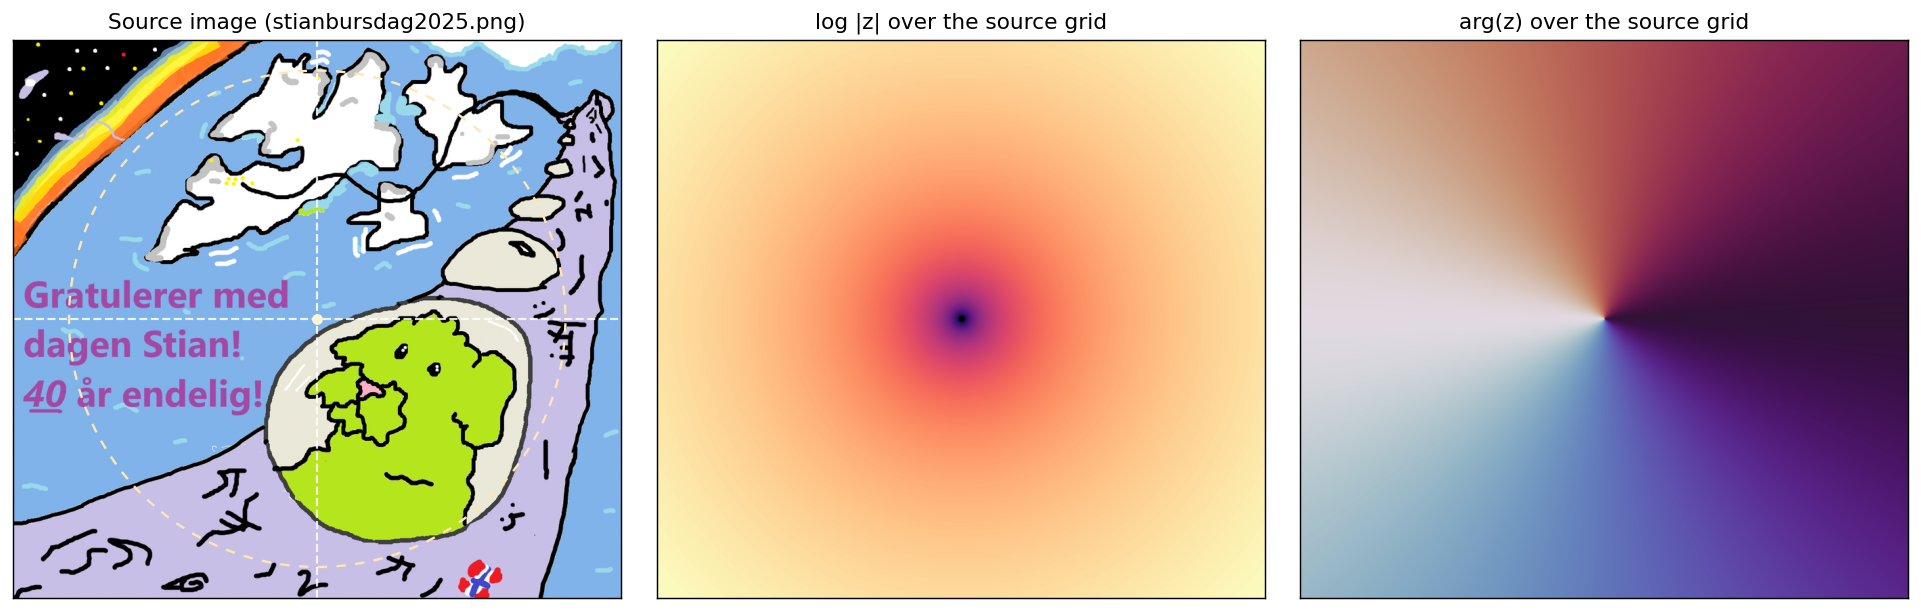

In [28]:
# For each source pixel, compute
#   z = x + i y,
# then take the principal logarithm
#   w = log(z) = log|z| + i arg(z).
# This splits the geometry into radius |z| and angle arg(z).
parts = cip.principal_log_decomposition(image.shape, origin_px, pixels_per_unit, inner_cutoff_px=inner_cutoff_px)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

cip.plot_image(axes[0], image, f"Source image ({image_label})")
cip.annotate_source_plane(axes[0], image.shape, origin_px, pixels_per_unit)

# Re(w) = log|z|, so this plot tracks radial distance from the chosen origin.
axes[1].imshow(np.log(np.maximum(parts["radius"], parts["min_radius"])), cmap="magma")
axes[1].set_title("log |z| over the source grid")
axes[1].set_xticks([])
axes[1].set_yticks([])

# Im(w) = arg(z), so this plot tracks angular position around the origin.
axes[2].imshow(parts["angle"], cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[2].set_title("arg(z) over the source grid")
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()

## 2. Render The Principal Log Plane

To visualize `w = log(z)`, we sample a rectangular window in the `w`-plane. Each point `w = u + iv` is sent back to the source image through `z = exp(w)`.

This is the cleanest place to see why the logarithm turns radial structure into horizontal structure and angular structure into vertical structure.

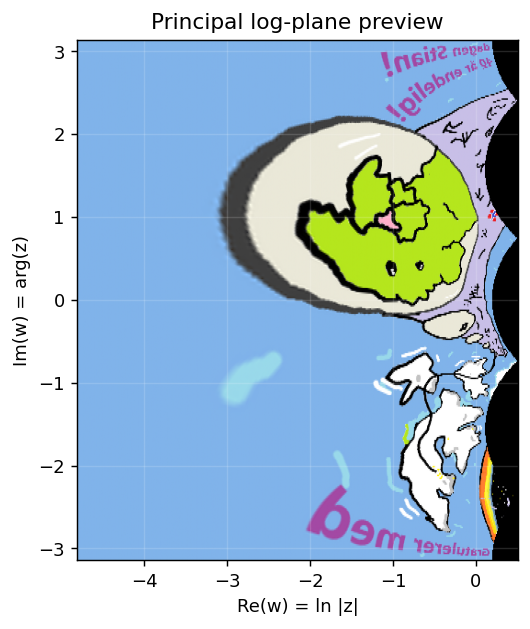

In [29]:
# Build a rectangular grid directly in the log plane:
#   w = u + i v,
# where u = log|z| and v = arg(z).
# To render that grid as an image, the helper maps each w back through
#   z = exp(w)
# and samples the original source image at that complex location.
log_preview = cip.render_log_plane_preview(
    image,
    origin_px,
    pixels_per_unit,
    output_shape=(360, 480),
    inner_cutoff_px=inner_cutoff_px,
)

u0, u1 = log_preview["u_range"]
v0, v1 = log_preview["v_range"]

fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.imshow(log_preview["image"], extent=(u0, u1, v0, v1), origin="lower")
ax.set_title("Principal log-plane preview")
ax.set_xlabel("Re(w) = ln |z|")
ax.set_ylabel("Im(w) = arg(z)")
ax.grid(color="white", alpha=0.15)

## 3. Apply A Complex Operation In Log Space

We now choose

$$w' = a w + b.$$

Useful interpretations:

- `a = 1` and varying `b` gives translation in log space, which becomes multiplication by `exp(b)` in the `z`-plane.
- Real `a > 1` behaves like a power map.
- Nonzero imaginary part in `a` mixes radial and angular information.
- When we render the transformed preview, we use inverse mapping: for each output point `w'`, we recover `w = (w' - b)/a`, then sample the source image at `z = exp(w)`.

z = ((x - x0) / s) + i((y0 - y) / s)
w = log(z)
w' = a w + b
z' = exp(w')

origin_px = (450.0, 413.0)
pixels_per_unit = 367.11
inner_cutoff_px = 3.00
a = 1.000 + -1.000i
b = 0.000 + 0.000i

Re(z) in [-1.23, 1.23]
Im(z) in [-1.12, 1.12]
Re(w) in [-4.81, 0.51]
Im(w) in [-pi, pi]
Complex multiply check: max |aw - component_formula| = 0.000e+00
Example: the center pixel of the output log-grid
  w' = -2.143 - 0.009i
  w  = -1.067 - 1.076i
  a*w = -2.143 - 0.009i
  a*w+b = -2.143 - 0.009i
  z  = 0.163 - 0.303i
  max |(a*w+b) - w'| over the grid = 4.965e-16


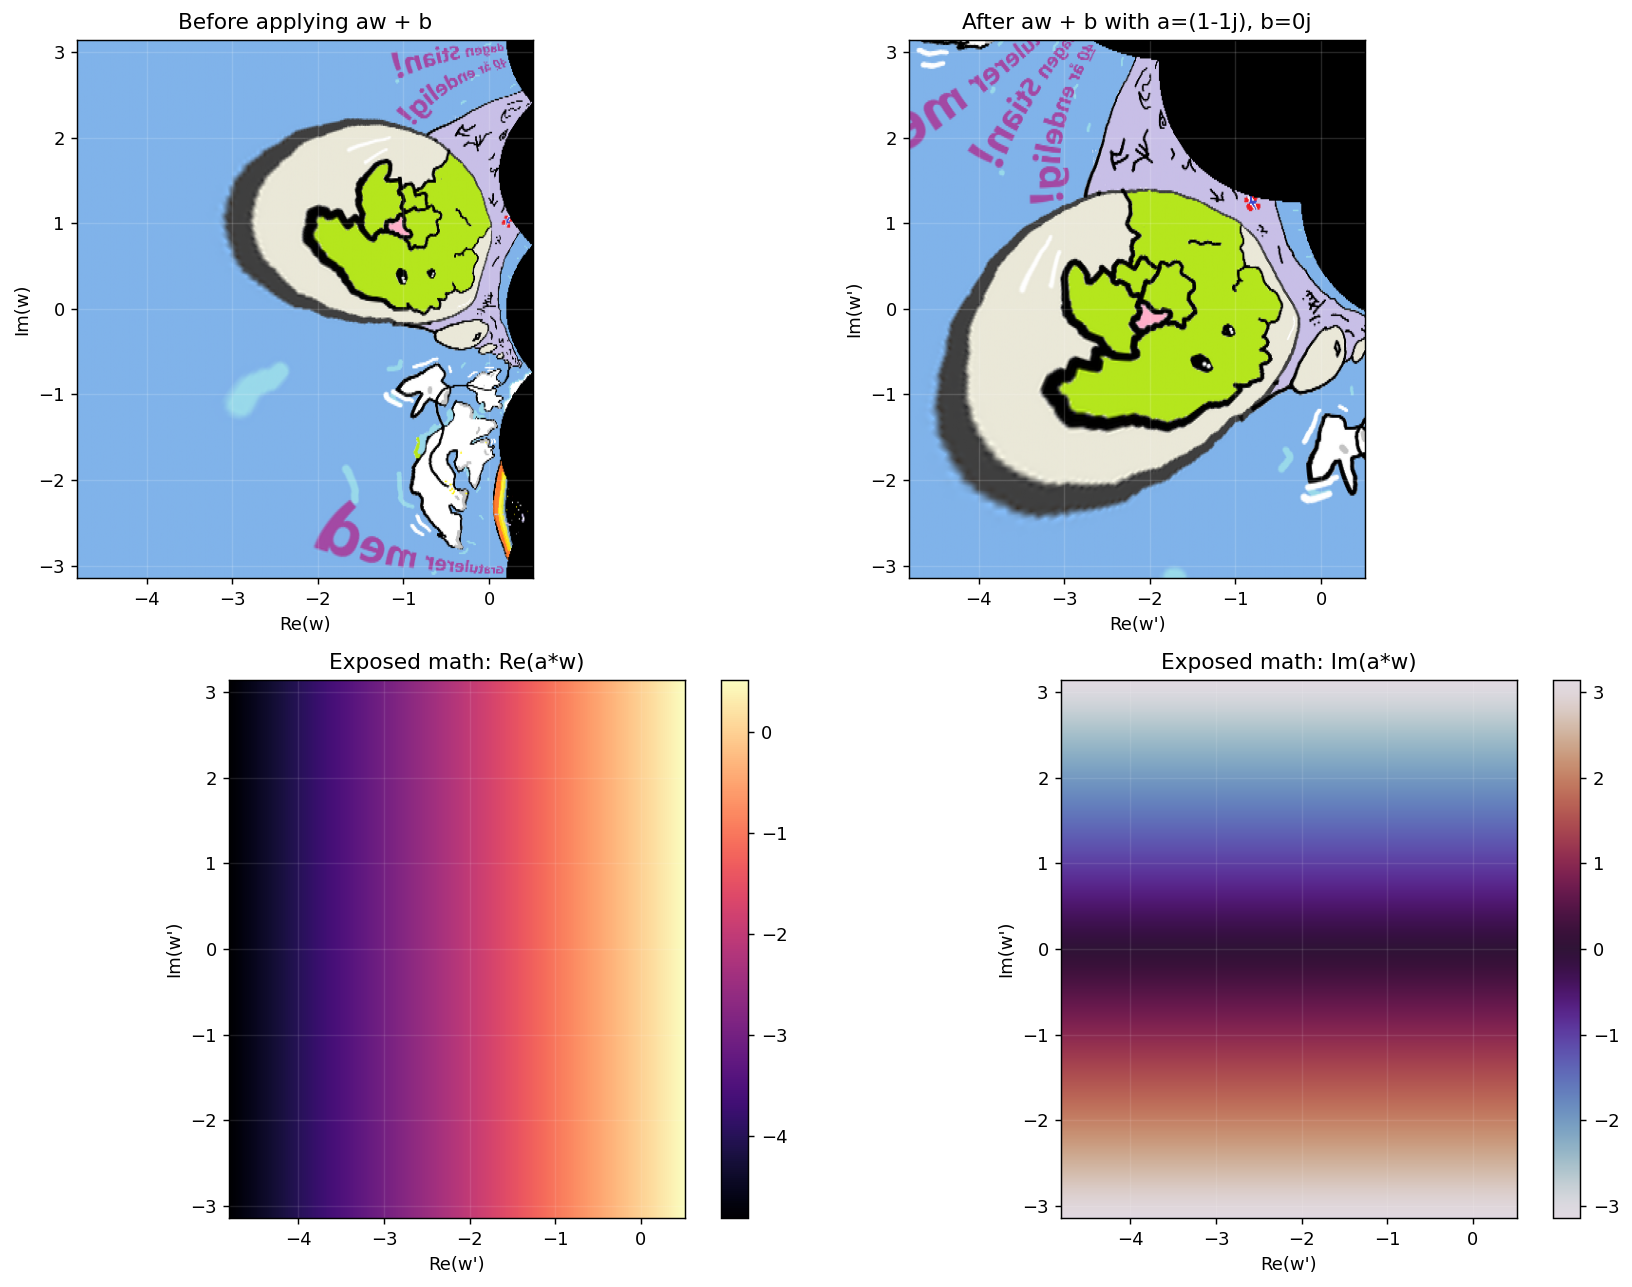

In [66]:
# Choose the affine map in log space
#   w' = a w + b.
# - Changing b translates the log plane and becomes multiplication by exp(b) in z-space.
# - Changing a stretches/rotates the log plane, and real a > 1 behaves like a power map.
a = 1.0 - 1.0j
b = 0.0 + 0.0j  # try 0.45 + 0.80j

log_step = cip.render_log_plane_preview(
    image,
    origin_px,
    pixels_per_unit,
    output_shape=(360, 480),
    inner_cutoff_px=inner_cutoff_px,
    a=a,
    b=b,
    inverse_affine=True,
)

# The rendered canvas lives in output coordinates w' = u + iv.
w_prime = log_step["w_prime"]

# Because images are rendered by inverse mapping, we do not push pixels forward.
# Instead, every output location asks where in the source it should sample from.
# So we undo the user's map
#   w' = a w + b
# by solving
#   w = (w' - b) / a
# for every output pixel.
w_source = log_step["w_source"]

# THIS is the complex multiplication in notebook code.
# Write
#   a = a_r + i a_i
#   w = u + i v.
# Then
#   a w = (a_r u - a_i v) + i(a_r v + a_i u).
a_r, a_i = a.real, a.imag
u = np.real(w_source)
v = np.imag(w_source)
aw_from_components = (a_r * u - a_i * v) + 1j * (a_r * v + a_i * u)

# Same multiplication, but using NumPy's built-in complex arithmetic.
aw = a * w_source

# Then add the translation term b to complete the affine map.
aw_plus_b = aw + b

# Returning to the source complex plane is the exponential step
#   z = exp(w) = exp(Re(w)) * (cos(Im(w)) + i sin(Im(w))).
z_source = np.exp(w_source)

center_row = w_prime.shape[0] // 2
center_col = w_prime.shape[1] // 2
component_error = np.nanmax(np.abs(aw - aw_from_components))
forward_error = np.nanmax(np.abs(aw_plus_b - w_prime))

def fmt_complex(z):
    return f"{z.real:.3f} {'+' if z.imag >= 0 else '-'} {abs(z.imag):.3f}i"


print(cip.describe_mapping(image.shape, origin_px, pixels_per_unit, a=a, b=b, inner_cutoff_px=inner_cutoff_px))
print(f"Complex multiply check: max |aw - component_formula| = {component_error:.3e}")

# A concrete sample point helps track the algebra numerically.
print("Example: the center pixel of the output log-grid")
print(f"  w' = {fmt_complex(w_prime[center_row, center_col])}")
print(f"  w  = {fmt_complex(w_source[center_row, center_col])}")
print(f"  a*w = {fmt_complex(aw[center_row, center_col])}")
print(f"  a*w+b = {fmt_complex(aw_plus_b[center_row, center_col])}")
print(f"  z  = {fmt_complex(z_source[center_row, center_col])}")
print(f"  max |(a*w+b) - w'| over the grid = {forward_error:.3e}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(log_preview["image"], extent=(u0, u1, v0, v1), origin="lower")
axes[0, 0].set_title("Before applying aw + b")
axes[0, 0].set_xlabel("Re(w)")
axes[0, 0].set_ylabel("Im(w)")
axes[0, 0].grid(color="white", alpha=0.15)

axes[0, 1].imshow(log_step["image"], extent=(u0, u1, v0, v1), origin="lower")
axes[0, 1].set_title(f"After aw + b with a={a}, b={b}")
axes[0, 1].set_xlabel("Re(w')")
axes[0, 1].set_ylabel("Im(w')")
axes[0, 1].grid(color="white", alpha=0.15)

im_radius = axes[1, 0].imshow(np.real(aw), extent=(u0, u1, v0, v1), origin="lower", cmap="magma")
axes[1, 0].set_title("Exposed math: Re(a*w)")
axes[1, 0].set_xlabel("Re(w')")
axes[1, 0].set_ylabel("Im(w')")
axes[1, 0].grid(color="white", alpha=0.10)
fig.colorbar(im_radius, ax=axes[1, 0], fraction=0.046, pad=0.04)

im_angle = axes[1, 1].imshow(np.imag(aw), extent=(u0, u1, v0, v1), origin="lower", cmap="twilight")
axes[1, 1].set_title("Exposed math: Im(a*w)")
axes[1, 1].set_xlabel("Re(w')")
axes[1, 1].set_ylabel("Im(w')")
axes[1, 1].grid(color="white", alpha=0.10)
fig.colorbar(im_angle, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()

In [ ]:
# Build a genuinely doubly periodic operated W-plane.
# Choose a rectangle in the source log plane
#   w = u + i v,  with u = log|z| and v = arg(z).
# Under the affine map
#   w' = a*w + b,
# this rectangle becomes a parallelogram in the operated W-plane.
# Its two lattice-period vectors are
#   T_u = a * L
#   T_v = a * (i * V),
# where L is the chosen horizontal width and V is the chosen vertical height.

horizontal_axis = "log_radius"  # "log_radius" or "radius"

# Choose the rectangle in the source log plane.
u_min = -1.55
u_max = 0.50

radius_min = 0.35
radius_max = 1.80

angle_min = -1.0 * np.pi
angle_max = 1.0 * np.pi

tile_shape = (360, 480)

# Choose an axis-aligned window only for visualizing the operated W-plane lattice.
periodic_view_u_min = -8.0
periodic_view_u_max = 0.5
periodic_view_v_min = -np.pi
periodic_view_v_max = np.pi

operated_w_plane = log_step["image"]
full_h, full_w = operated_w_plane.shape[:2]
full_u0, full_u1 = map(float, log_step["u_range"])
full_v0, full_v1 = map(float, log_step["v_range"])
background = np.zeros(operated_w_plane.shape[2], dtype=np.float64)

if horizontal_axis == "log_radius":
    if not (u_max > u_min):
        raise ValueError("Need u_max > u_min when horizontal_axis='log_radius'.")
    tile_u0 = float(u_min)
    tile_u1 = float(u_max)
    radius_min = np.exp(tile_u0)
    radius_max = np.exp(tile_u1)
elif horizontal_axis == "radius":
    if not (0.0 < radius_min < radius_max):
        raise ValueError("Need 0 < radius_min < radius_max when horizontal_axis='radius'.")
    tile_u0 = np.log(radius_min)
    tile_u1 = np.log(radius_max)
else:
    raise ValueError("horizontal_axis must be 'log_radius' or 'radius'.")

tile_v0 = float(angle_min)
tile_v1 = float(angle_max)
tile_h, tile_w = tile_shape
L = tile_u1 - tile_u0
V = tile_v1 - tile_v0

if not (L > 0.0):
    raise ValueError("Need tile_u1 > tile_u0.")
if not (V > 0.0):
    raise ValueError("Need tile_v1 > tile_v0.")
if not (periodic_view_u_max > periodic_view_u_min):
    raise ValueError("Need periodic_view_u_max > periodic_view_u_min.")
if not (periodic_view_v_max > periodic_view_v_min):
    raise ValueError("Need periodic_view_v_max > periodic_view_v_min.")

# This is the chosen source-log rectangle:
#   tile_u0 < Re(w) < tile_u1,
#   tile_v0 < Im(w) < tile_v1.
tile_u = np.linspace(tile_u0, tile_u1, tile_w)
tile_v = np.linspace(tile_v0, tile_v1, tile_h)
W_source_tile = tile_u[None, :] + 1j * tile_v[:, None]

# The source-log tile is sampled directly from z = exp(w).
Z_source_tile = np.exp(W_source_tile)
selected_w_tile = cip.sample_source_from_complex(
    image,
    Z_source_tile,
    origin_px,
    pixels_per_unit,
    fill_value=background,
)

# Complex multiplication maps that source rectangle to a parallelogram in the operated W-plane.
source_anchor = tile_u0 + 1j * tile_v0
operated_anchor = a * source_anchor + b
period_u = a * L
period_v = a * (1j * V)

if abs(period_u.real * period_v.imag - period_u.imag * period_v.real) < 1e-12:
    raise ValueError("The two operated-plane period vectors became linearly dependent.")

# The operated parallelogram corners are the image of the source rectangle corners under w' = a*w + b.
parallelogram = np.array(
    [
        operated_anchor,
        operated_anchor + period_u,
        operated_anchor + period_u + period_v,
        operated_anchor + period_v,
        operated_anchor,
    ],
    dtype=np.complex128,
)

# The intrinsic tile coordinates (s, t) run across the source rectangle.
# After multiplication by a, those same coordinates parametrize the operated parallelogram.
s = np.linspace(0.0, 1.0, tile_w)
t = np.linspace(0.0, 1.0, tile_h)
S, T = np.meshgrid(s, t)
W_operated_tile = operated_anchor + S * period_u + T * period_v

# This is only a display coverage check: it tells us how much of the chosen parallelogram
# lies inside the finite rendered operated preview log_step["image"].
u_from_full_tile = (np.real(W_operated_tile) - full_u0) / (full_u1 - full_u0) * (full_w - 1)
v_from_full_tile = (np.imag(W_operated_tile) - full_v0) / (full_v1 - full_v0) * (full_h - 1)
tile_inside_preview = (
    (u_from_full_tile >= 0.0)
    & (u_from_full_tile <= full_w - 1)
    & (v_from_full_tile >= 0.0)
    & (v_from_full_tile <= full_h - 1)
)
tile_preview_coverage = float(np.mean(tile_inside_preview))

# Any operated-plane point satisfies
#   w' - operated_anchor = alpha * T_u + beta * T_v.
# Solving for (alpha, beta) gives lattice coordinates in the period basis.
basis = np.array(
    [
        [period_u.real, period_v.real],
        [period_u.imag, period_v.imag],
    ],
    dtype=np.float64,
)
basis_inv = np.linalg.inv(basis)

def lattice_coordinates(w_complex):
    du = np.real(w_complex) - operated_anchor.real
    dv = np.imag(w_complex) - operated_anchor.imag
    alpha = basis_inv[0, 0] * du + basis_inv[0, 1] * dv
    beta = basis_inv[1, 0] * du + basis_inv[1, 1] * dv
    return alpha, beta

# Double periodicity means
#   G(w' + m*T_u + n*T_v) = G(w')
# for all integers m, n.
pixels_per_u = (full_w - 1) / (full_u1 - full_u0)
pixels_per_v = (full_h - 1) / (full_v1 - full_v0)
periodic_w = int(np.ceil((periodic_view_u_max - periodic_view_u_min) * pixels_per_u)) + 1
periodic_h = int(np.ceil((periodic_view_v_max - periodic_view_v_min) * pixels_per_v)) + 1
periodic_u = np.linspace(periodic_view_u_min, periodic_view_u_max, periodic_w)
periodic_v = np.linspace(periodic_view_v_min, periodic_view_v_max, periodic_h)
U_periodic, V_periodic = np.meshgrid(periodic_u, periodic_v)
W_periodic = U_periodic + 1j * V_periodic

alpha_periodic, beta_periodic = lattice_coordinates(W_periodic)
alpha_wrapped = np.mod(alpha_periodic, 1.0)
beta_wrapped = np.mod(beta_periodic, 1.0)

u_from_tile_periodic = alpha_wrapped * (tile_w - 1)
v_from_tile_periodic = beta_wrapped * (tile_h - 1)
periodic_w_plane = cip.bilinear_sample(
    selected_w_tile,
    u_from_tile_periodic,
    v_from_tile_periodic,
    fill_value=background,
)

# The final z-plane output samples the lattice-periodic operated W-plane at
#   w' = log(z') = log|z'| + i arg(z').
out_h, out_w = image.shape[:2]
cx, cy = origin_px
Y, X = np.mgrid[0:out_h, 0:out_w]
dx = X - cx
dy = cy - Y
r_pixels = np.sqrt(dx * dx + dy * dy)
valid = r_pixels > 1e-12
theta = np.arctan2(dy, dx)

alpha_world = np.full_like(r_pixels, np.nan, dtype=np.float64)
beta_world = np.full_like(r_pixels, np.nan, dtype=np.float64)
w_prime_world = np.full(r_pixels.shape, np.nan + 1j * np.nan, dtype=np.complex128)
w_prime_world[valid] = np.log(r_pixels[valid] / pixels_per_unit) + 1j * theta[valid]

alpha_valid, beta_valid = lattice_coordinates(w_prime_world[valid])
alpha_world[valid] = np.mod(alpha_valid, 1.0)
beta_world[valid] = np.mod(beta_valid, 1.0)

u_from_tile_output = alpha_world * (tile_w - 1)
v_from_tile_output = beta_world * (tile_h - 1)
periodic_output = cip.bilinear_sample(
    selected_w_tile,
    u_from_tile_output,
    v_from_tile_output,
    fill_value=background,
)
periodic_output[~valid] = background

source_box_u = [tile_u0, tile_u1, tile_u1, tile_u0, tile_u0]
source_box_v = [tile_v0, tile_v0, tile_v1, tile_v1, tile_v0]
parallelogram_u = np.real(parallelogram)
parallelogram_v = np.imag(parallelogram)

fig, axes = plt.subplots(2, 2, figsize=(14.5, 10.5))

axes[0, 0].imshow(operated_w_plane, extent=(full_u0, full_u1, full_v0, full_v1), origin="lower")
axes[0, 0].plot(parallelogram_u, parallelogram_v, color="white", linewidth=2)
axes[0, 0].quiver(
    [operated_anchor.real, operated_anchor.real],
    [operated_anchor.imag, operated_anchor.imag],
    [period_u.real, period_v.real],
    [period_u.imag, period_v.imag],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color=["white", "gold"],
    width=0.004,
)
axes[0, 0].set_title(f"Operated W-plane after w' = a*w + b, a={a}, b={b}")
axes[0, 0].set_xlabel("u' = Re(w')")
axes[0, 0].set_ylabel("v' = Im(w')")
axes[0, 0].grid(color="white", alpha=0.12)

axes[0, 1].imshow(selected_w_tile, extent=(tile_u0, tile_u1, tile_v0, tile_v1), origin="lower")
axes[0, 1].set_title("Chosen source rectangle in the log plane")
axes[0, 1].set_xlabel("u = log|z|")
axes[0, 1].set_ylabel("v = arg(z)")
axes[0, 1].grid(color="white", alpha=0.12)

axes[1, 0].imshow(
    periodic_w_plane,
    extent=(periodic_view_u_min, periodic_view_u_max, periodic_view_v_min, periodic_view_v_max),
    origin="lower",
)
axes[1, 0].plot(parallelogram_u, parallelogram_v, color="white", linewidth=1.6)
axes[1, 0].set_title("Lattice-periodic operated W-plane")
axes[1, 0].set_xlabel("u' = Re(w')")
axes[1, 0].set_ylabel("v' = Im(w')")
axes[1, 0].grid(color="white", alpha=0.12)

axes[1, 1].imshow(np.clip(periodic_output, 0.0, 1.0))
axes[1, 1].set_title("z-plane sampled from the doubly periodic operated W-plane")
axes[1, 1].set_xticks([])
axes[1, 1].set_yticks([])

def fmt_period(z):
    return f"{z.real:.3f} {'+' if z.imag >= 0 else '-'} {abs(z.imag):.3f}i"

print(f"Chosen source-log rectangle: {tile_u0:.3f} < Re(w) < {tile_u1:.3f}")
print(f"Equivalent radius interval: {radius_min:.3f} < |z| < {radius_max:.3f}")
print(f"Chosen source angle interval: {tile_v0:.3f} < Im(w) < {tile_v1:.3f}")
print(f"Operated-plane period T_u = {fmt_period(period_u)}")
print(f"Operated-plane period T_v = {fmt_period(period_v)}")
print(f"Horizontal source period L gives scale factor exp(L) = {np.exp(L):.3f}")
print(f"Display coverage of the operated parallelogram inside log_step preview: {tile_preview_coverage:.1%}")
if abs(V - 2.0 * np.pi) > 1e-6:
    print("Note: choose a vertical period of 2*pi for exact exp-periodicity in the angle direction.")

plt.tight_layout()


## 4. Map Back With The Exponential

For each output-plane point `z'`, we compute the principal logarithm `w' = log(z')`, invert the affine step to recover `w = (w' - b)/a`, and then recover the source position through `z = exp(w)`.

This is the step where the branch cut becomes visible.

In [ ]:
# Compare the plain exp-map output to the output obtained from the doubly periodic operated W-plane.
# Plain output: apply w' = a*w + b and then return with z = exp(w).
plain_output = cip.render_output_plane(
    image,
    origin_px,
    pixels_per_unit,
    a=a,
    b=b,
    output_shape=image.shape[:2],
)

fig, axes = plt.subplots(2, 3, figsize=(17, 10.5))

cip.plot_image(axes[0, 0], image, "Source z-plane")
cip.annotate_source_plane(axes[0, 0], image.shape, origin_px, pixels_per_unit)

axes[0, 1].imshow(log_preview["image"], extent=(u0, u1, v0, v1), origin="lower")
axes[0, 1].plot(source_box_u, source_box_v, color="white", linewidth=2)
axes[0, 1].set_title("Chosen source rectangle in the log plane")
axes[0, 1].set_xlabel("Re(w)")
axes[0, 1].set_ylabel("Im(w)")

axes[0, 2].imshow(operated_w_plane, extent=(full_u0, full_u1, full_v0, full_v1), origin="lower")
axes[0, 2].plot(parallelogram_u, parallelogram_v, color="white", linewidth=2)
axes[0, 2].quiver(
    [operated_anchor.real, operated_anchor.real],
    [operated_anchor.imag, operated_anchor.imag],
    [period_u.real, period_v.real],
    [period_u.imag, period_v.imag],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color=["white", "gold"],
    width=0.004,
)
axes[0, 2].set_title("Operated W-plane with its fundamental parallelogram")
axes[0, 2].set_xlabel("u' = Re(w')")
axes[0, 2].set_ylabel("v' = Im(w')")

axes[1, 0].imshow(
    periodic_w_plane,
    extent=(periodic_view_u_min, periodic_view_u_max, periodic_view_v_min, periodic_view_v_max),
    origin="lower",
)
axes[1, 0].plot(parallelogram_u, parallelogram_v, color="white", linewidth=1.6)
axes[1, 0].set_title("Doubly periodic operated W-plane")
axes[1, 0].set_xlabel("u' = Re(w')")
axes[1, 0].set_ylabel("v' = Im(w')")

cip.plot_image(axes[1, 1], plain_output["image"], "Plain exp-map output")
cip.annotate_source_plane(axes[1, 1], plain_output["image"].shape, origin_px, pixels_per_unit)

cip.plot_image(axes[1, 2], periodic_output, "Output from the doubly periodic operated W-plane")
cip.annotate_source_plane(axes[1, 2], periodic_output.shape, origin_px, pixels_per_unit)

plt.tight_layout()


## Suggested Experiments

- Keep `a = 1` and vary `b` to study how translation in log space becomes multiplication in the image plane.
- Try `a = 2 + 0j` to see a power-like effect.
- Try `a = 0.5 + 0j` to see a root-like compression.
- Give `a` a nonzero imaginary part to mix radius and angle.
- Move `origin_px` away from the image center and watch how the branch cut and spiral structure change.
- Replace the demo image with a photograph, logo, or diagram and compare which structures survive the branch cut best.